In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, Birch, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

import joblib

In [ ]:

CSV_PATH = "data.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"File not found: {CSV_PATH}\n"
        "Download from Kaggle and place it here, or update CSV_PATH."
    )

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head(3)

Shape: (47837, 2)
Columns: ['Document', 'Topic_group']


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


In [4]:
TEXT_COL_CANDIDATES = ["Document", "document", "text", "description", "Description", "body", "Body"]
LABEL_COL_CANDIDATES = ["Topic_group", "topic_group", "Category", "category", "label", "Label"]

def pick_first_existing(cands, cols):
    for c in cands:
        if c in cols:
            return c
    return None

text_col = pick_first_existing(TEXT_COL_CANDIDATES, df.columns)
label_col = pick_first_existing(LABEL_COL_CANDIDATES, df.columns)

if text_col is None:
    raise ValueError(f"No text column found. Tried: {TEXT_COL_CANDIDATES}")

print("Using text column:", text_col)
print("Using label column:", label_col)

keep_cols = [text_col] + ([label_col] if label_col is not None else [])
df = df[keep_cols].copy()

df = df.dropna(subset=[text_col]).copy()
df[text_col] = df[text_col].astype(str)
df.head(3)

Using text column: Document
Using label column: Topic_group


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


In [5]:
CI_PHRASES = [
    r"\bconfiguration\s*item\b",
    r"\bci\s*name\b",
    r"\bcmdb\b",
    r"\basset\s*id\b",
    r"\basset\s*tag\b",
    r"\bserial\s*(no|number)\b",
    r"\bhostname\b",
    r"\bhost\s*name\b",
    r"\bdevice\s*name\b",
]

def strip_ci_and_assets(text: str) -> str:
    t = text

    # remove URLs and emails
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", t)

    # remove IP addresses
    t = re.sub(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", " ", t)

    # remove FQDN hostnames like server01.domain.com
    t = re.sub(r"\b[a-zA-Z0-9-]+\.(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}\b", " ", t)

    # remove ticket ids like INC1234567, CHG0001234, RITM0012345
    t = re.sub(r"\b(?:inc|chg|ritm|req|sr|prb)\d{4,}\b", " ", t, flags=re.IGNORECASE)

    # remove asset-like tokens (mixed letters+digits, length>=6)
    t = re.sub(r"\b(?=[A-Za-z0-9_-]*\d)(?=[A-Za-z0-9_-]*[A-Za-z])[A-Za-z0-9_-]{6,}\b", " ", t)

    # remove bracketed metadata often containing CI identifiers
    t = re.sub(r"\[[^\]]{0,120}\]", " ", t)
    t = re.sub(r"\([^\)]{0,120}\)", " ", t)
    t = re.sub(r"\{[^\}]{0,120}\}", " ", t)

    # remove explicit CI phrases
    for p in CI_PHRASES:
        t = re.sub(p, " ", t, flags=re.IGNORECASE)

    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text_wo_ci"] = df[text_col].apply(strip_ci_and_assets)

# Quick before/after sample
for i in range(3):
    print("\n--- SAMPLE", i, "---")
    print("ORIG :", df[text_col].iloc[i][:300])
    print("CLEAN:", df["text_wo_ci"].iloc[i][:300])


--- SAMPLE 0 ---
ORIG : connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
CLEAN: connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

--- SAMPLE 1 ---
ORIG : work experience user work experience user hi work experience student coming next his name much appreciate him duration thank
CLEAN: work experience user work experience user hi work experience student coming next his name much appreciate him duration thank

--- SAMPLE 2 ---
ORIG : requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug
CLEAN: requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug


In [6]:
def clean_text(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean_text"] = df["text_wo_ci"].apply(clean_text)
df["char_len"] = df["clean_text"].str.len()
df["word_len"] = df["clean_text"].apply(lambda x: len(x.split()))

df.head(3)

,Document,Topic_group,text_wo_ci,clean_text,char_len,word_len
0,connection with icon icon dear please setup ic...,Hardware,connection with icon icon dear please setup ic...,connection with icon icon dear please setup ic...,111,18
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...,work experience user work experience user hi w...,124,19
2,requesting for meeting requesting meeting hi p...,Hardware,requesting for meeting requesting meeting hi p...,requesting for meeting requesting meeting hi p...,93,14


In [7]:
before = len(df)
df = df[(df["word_len"] >= 8) & (df["word_len"] <= 250)].copy()
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f"Rows before: {before}, after filtering: {after}")
df[["word_len", "char_len"]].describe()

Rows before: 47837, after filtering: 46241


,word_len,char_len
count,46241.000000,46241.000000
mean,39.696892,265.288597
std,37.730431,257.755964
min,8.000000,26.000000
25%,17.000000,112.000000
50%,27.000000,176.000000
75%,45.000000,299.000000
max,250.000000,2063.000000


In [8]:
print("==== Missing values ====")
print(df.isna().sum())

print("\n==== Word length stats ====")
print(df["word_len"].describe())

print("\n==== Char length stats ====")
print(df["char_len"].describe())

if label_col is not None and label_col in df.columns:
    print("\n==== Label distribution (Top 15) ====")
    print(df[label_col].value_counts().head(15))

==== Missing values ====
Document       0
Topic_group    0
text_wo_ci     0
clean_text     0
char_len       0
word_len       0
dtype: int64

==== Word length stats ====
count    46241.000000
mean        39.696892
std         37.730431
min          8.000000
25%         17.000000
50%         27.000000
75%         45.000000
max        250.000000
Name: word_len, dtype: float64

==== Char length stats ====
count    46241.000000
mean       265.288597
std        257.755964
min         26.000000
25%        112.000000
50%        176.000000
75%        299.000000
max       2063.000000
Name: char_len, dtype: float64

==== Label distribution (Top 15) ====
Topic_group
Hardware                 13031
HR Support               10576
Miscellaneous             6898
Access                    6816
Storage                   2706
Purchase                  2452
Internal Project          2080
Administrative rights     1682
Name: count, dtype: int64


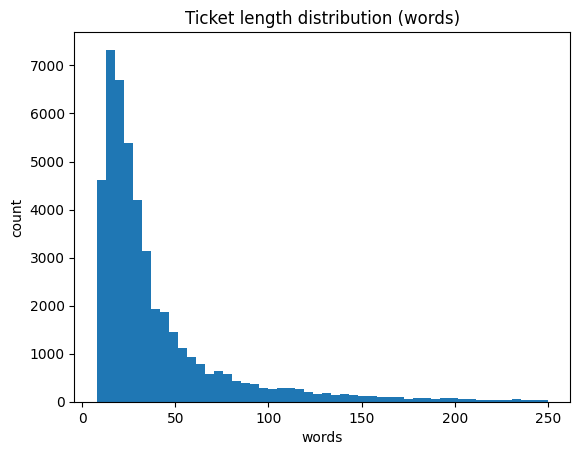

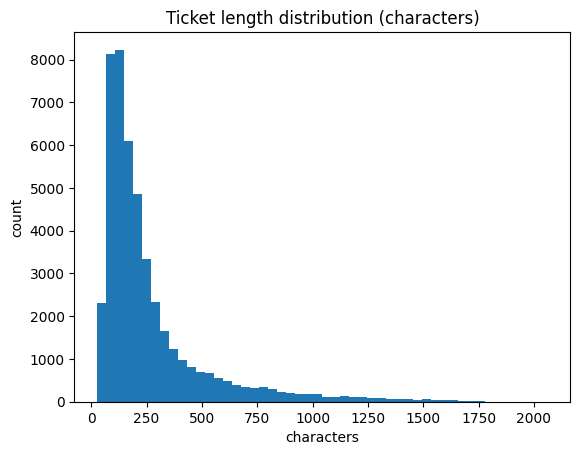

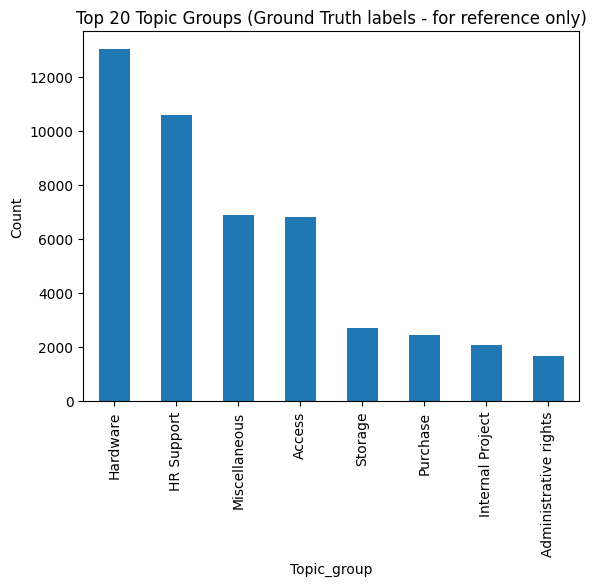

In [9]:
plt.figure()
plt.hist(df["word_len"], bins=50)
plt.title("Ticket length distribution (words)")
plt.xlabel("words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(df["char_len"], bins=50)
plt.title("Ticket length distribution (characters)")
plt.xlabel("characters")
plt.ylabel("count")
plt.show()

if label_col is not None and label_col in df.columns:
    top = df[label_col].value_counts().head(20)
    plt.figure()
    top.plot(kind="bar")
    plt.title("Top 20 Topic Groups (Ground Truth labels - for reference only)")
    plt.xlabel("Topic_group")
    plt.ylabel("Count")
    plt.show()

In [10]:
from collections import Counter

tokens = " ".join(df["clean_text"].tolist()).split()
wc = Counter(tokens)
common_words = pd.DataFrame(wc.most_common(30), columns=["word", "count"])
common_words

,word,count
0,please,64797
1,pm,26824
2,hi,25951
3,regards,24498
4,thank,22894
5,for,21672
6,hello,21108
7,you,18664
8,thanks,18259
9,re,16835


In [11]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["clean_text"])
X_tfidf = normalize(X_tfidf)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (46241, 38699)


In [12]:
N_COMPONENTS = 100  # good default
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_red = svd.fit_transform(X_tfidf)

print("Reduced shape:", X_red.shape)
print("Explained variance (sum):", float(svd.explained_variance_ratio_.sum()))

Reduced shape: (46241, 100)
Explained variance (sum): 0.17406561369205184


In [13]:
def cluster_metrics(X, labels):
    # labels may contain noise (-1) for DBSCAN
    unique = np.unique(labels)
    n_clusters = len(unique) - (1 if -1 in unique else 0)

    # If everything is one cluster or all noise, metrics not valid
    if n_clusters <= 1:
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "dbi": np.nan,
            "calinski": np.nan
        }

    mask = labels != -1
    X_eval = X[mask]
    y_eval = labels[mask]

    return {
        "n_clusters": n_clusters,
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "dbi": float(davies_bouldin_score(X_eval, y_eval)),
        "calinski": float(calinski_harabasz_score(X_eval, y_eval))
    }

In [14]:
kmeans_rows = []
for k in range(2, 21):
    model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    labels = model.fit_predict(X_red)
    m = cluster_metrics(X_red, labels)
    kmeans_rows.append({"method":"KMeans", "param":k, **m})

kmeans_df = pd.DataFrame(kmeans_rows).sort_values("silhouette", ascending=False)
kmeans_df.head(10)

,method,param,n_clusters,silhouette,dbi,calinski
0,KMeans,2,2,0.303195,0.991007,503.199602
2,KMeans,4,4,0.251679,1.307496,1987.563022
18,KMeans,20,20,0.077465,2.373909,1022.954746
16,KMeans,18,18,0.068026,2.493667,1010.905703
12,KMeans,14,14,0.065083,2.808588,1080.927504
13,KMeans,15,15,0.060654,2.712623,993.585989
10,KMeans,12,12,0.059845,2.807005,1017.250636
17,KMeans,19,19,0.057965,2.635084,965.227130
15,KMeans,17,17,0.055928,2.489923,897.579401
8,KMeans,10,10,0.048738,2.580480,1116.892870


In [15]:
gmm_rows = []
for k in range(2, 21):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    labels = gmm.fit_predict(X_red)

    m = cluster_metrics(X_red, labels)
    gmm_rows.append({
        "method":"GMM",
        "param":k,
        "bic": float(gmm.bic(X_red)),
        "aic": float(gmm.aic(X_red)),
        **m
    })

gmm_df = pd.DataFrame(gmm_rows).sort_values("bic", ascending=True)
gmm_df.head(10)

,method,param,bic,aic,n_clusters,silhouette,dbi,calinski
18,GMM,20,-2.395818e+07,-2.485874e+07,20,-0.040855,4.440227,635.024211
17,GMM,19,-2.389121e+07,-2.474674e+07,19,-0.042701,4.534645,644.232811
16,GMM,18,-2.378909e+07,-2.459959e+07,18,-0.028359,4.616669,660.544379
14,GMM,16,-2.374888e+07,-2.446932e+07,16,-0.031237,4.808866,644.207216
15,GMM,17,-2.372162e+07,-2.448708e+07,17,-0.031314,4.571884,681.076449
12,GMM,14,-2.368305e+07,-2.431343e+07,14,-0.040501,5.316767,600.558320
13,GMM,15,-2.367681e+07,-2.435222e+07,15,-0.038577,5.082949,583.972941
11,GMM,13,-2.354552e+07,-2.413088e+07,13,-0.035270,5.551118,610.746538
10,GMM,12,-2.343480e+07,-2.397513e+07,12,-0.032572,5.307224,682.212252
9,GMM,11,-2.334820e+07,-2.384350e+07,11,-0.035040,5.733155,712.743054


In [16]:
agg_rows = []
for k in range(2, 21):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_red)
    m = cluster_metrics(X_red, labels)
    agg_rows.append({"method":"AgglomerativeWard", "param":k, **m})

agg_df = pd.DataFrame(agg_rows).sort_values("silhouette", ascending=False)
agg_df.head(10)

,method,param,n_clusters,silhouette,dbi,calinski
1,AgglomerativeWard,3,3,0.386843,0.937218,2456.120410
0,AgglomerativeWard,2,2,0.380662,1.159192,3553.776703
6,AgglomerativeWard,8,8,0.252448,1.376327,1593.340863
5,AgglomerativeWard,7,7,0.248301,1.566012,1669.695261
2,AgglomerativeWard,4,4,0.244804,0.996698,2094.865110
4,AgglomerativeWard,6,6,0.243050,1.519618,1773.014646
3,AgglomerativeWard,5,5,0.237671,1.595284,1931.275134
8,AgglomerativeWard,10,10,0.167395,1.410374,1460.274837
7,AgglomerativeWard,9,9,0.163006,1.432072,1528.298179
9,AgglomerativeWard,11,11,0.130788,1.655186,1399.641814


In [17]:
birch_rows = []
thresholds = [0.2, 0.35, 0.5, 0.7, 1.0]
for th in thresholds:
    brc = Birch(threshold=th, n_clusters=None)   # let it decide subclusters
    labels = brc.fit_predict(X_red)
    m = cluster_metrics(X_red, labels)
    birch_rows.append({"method":"Birch", "param":th, **m})

birch_df = pd.DataFrame(birch_rows).sort_values("silhouette", ascending=False)
birch_df

,method,param,n_clusters,silhouette,dbi,calinski
1,Birch,0.35,85,0.114298,1.803953,572.983394
0,Birch,0.20,11328,0.024183,1.152421,17.992715
2,Birch,0.50,1,NaN,NaN,NaN
3,Birch,0.70,1,NaN,NaN,NaN
4,Birch,1.00,1,NaN,NaN,NaN


In [18]:
dbscan_rows = []
eps_values = [0.3, 0.5, 0.7, 1.0, 1.3, 1.6]
for eps in eps_values:
    dbs = DBSCAN(eps=eps, min_samples=10)
    labels = dbs.fit_predict(X_red)
    m = cluster_metrics(X_red, labels)
    dbscan_rows.append({"method":"DBSCAN", "param":eps, **m})

dbscan_df = pd.DataFrame(dbscan_rows).sort_values("silhouette", ascending=False)
dbscan_df

,method,param,n_clusters,silhouette,dbi,calinski
0,DBSCAN,0.3,11,0.090162,0.800412,514.832197
1,DBSCAN,0.5,1,NaN,NaN,NaN
2,DBSCAN,0.7,1,NaN,NaN,NaN
3,DBSCAN,1.0,1,NaN,NaN,NaN
4,DBSCAN,1.3,1,NaN,NaN,NaN
5,DBSCAN,1.6,1,NaN,NaN,NaN


In [19]:
# Combine results (align columns)
kmeans_sel = kmeans_df.copy()
gmm_sel = gmm_df.copy()
agg_sel = agg_df.copy()
birch_sel = birch_df.copy()
dbscan_sel = dbscan_df.copy()

# For unified compare (GMM uses BIC separately, but we still compare silhouette)
for d in [kmeans_sel, agg_sel, birch_sel, dbscan_sel]:
    if "bic" not in d.columns:
        d["bic"] = np.nan
    if "aic" not in d.columns:
        d["aic"] = np.nan

# For GMM, keep both but don't sort by bic here (we already have gmm_df by bic)
if "bic" not in gmm_sel.columns:
    gmm_sel["bic"] = np.nan
if "aic" not in gmm_sel.columns:
    gmm_sel["aic"] = np.nan

all_results = pd.concat(
    [kmeans_sel, gmm_sel, agg_sel, birch_sel, dbscan_sel],
    ignore_index=True
)

# Drop invalid rows where silhouette is nan
all_valid = all_results.dropna(subset=["silhouette"]).copy()

# Rank: high silhouette, low dbi
all_valid = all_valid.sort_values(["silhouette", "dbi"], ascending=[False, True])

all_valid.head(15)

,method,param,n_clusters,silhouette,dbi,calinski,bic,aic
38,AgglomerativeWard,3.00,3,0.386843,0.937218,2456.120410,NaN,NaN
39,AgglomerativeWard,2.00,2,0.380662,1.159192,3553.776703,NaN,NaN
0,KMeans,2.00,2,0.303195,0.991007,503.199602,NaN,NaN
40,AgglomerativeWard,8.00,8,0.252448,1.376327,1593.340863,NaN,NaN
1,KMeans,4.00,4,0.251679,1.307496,1987.563022,NaN,NaN
41,AgglomerativeWard,7.00,7,0.248301,1.566012,1669.695261,NaN,NaN
42,AgglomerativeWard,4.00,4,0.244804,0.996698,2094.865110,NaN,NaN
43,AgglomerativeWard,6.00,6,0.243050,1.519618,1773.014646,NaN,NaN
44,AgglomerativeWard,5.00,5,0.237671,1.595284,1931.275134,NaN,NaN
45,AgglomerativeWard,10.00,10,0.167395,1.410374,1460.274837,NaN,NaN


In [20]:
best = all_valid.iloc[0].to_dict()
best_method = best["method"]
best_param = best["param"]

print("==== BEST MODEL SELECTED ====")
print(best)

def fit_final_model(method, param, X):
    if method == "KMeans":
        model = MiniBatchKMeans(n_clusters=int(param), random_state=42, batch_size=2048)
        labels = model.fit_predict(X)
        return model, labels

    if method == "GMM":
        model = GaussianMixture(n_components=int(param), covariance_type="full", random_state=42)
        labels = model.fit_predict(X)
        return model, labels

    if method == "AgglomerativeWard":
        model = AgglomerativeClustering(n_clusters=int(param), linkage="ward")
        labels = model.fit_predict(X)
        return model, labels

    if method == "Birch":
        model = Birch(threshold=float(param), n_clusters=None)
        labels = model.fit_predict(X)
        return model, labels

    if method == "DBSCAN":
        model = DBSCAN(eps=float(param), min_samples=10)
        labels = model.fit_predict(X)
        return model, labels

    raise ValueError("Unknown method")

final_model, final_labels = fit_final_model(best_method, best_param, X_red)
df["cluster"] = final_labels

df["cluster"].value_counts().head(20)

==== BEST MODEL SELECTED ====
{'method': 'AgglomerativeWard', 'param': 3.0, 'n_clusters': 3, 'silhouette': 0.3868427308436359, 'dbi': 0.9372176267923115, 'calinski': 2456.1204101031603, 'bic': nan, 'aic': nan}


cluster
0    44657
1     1348
2      236
Name: count, dtype: int64

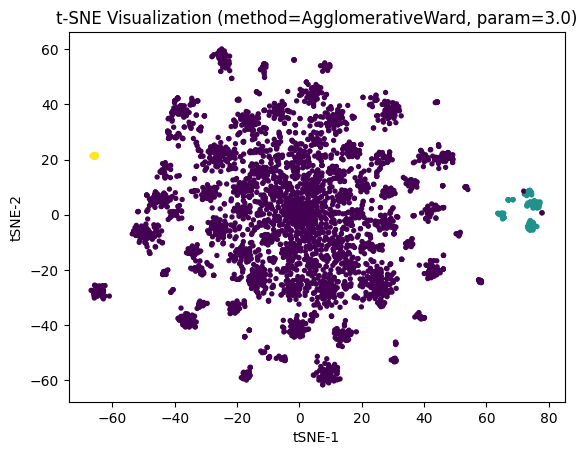

In [21]:
# t-SNE can be slow for huge datasets; sample if needed
SAMPLE_N = min(4000, len(df))
sample_idx = np.random.RandomState(42).choice(len(df), size=SAMPLE_N, replace=False)

X_sample = X_red[sample_idx]
y_sample = df["cluster"].iloc[sample_idx].values

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
X_2d = tsne.fit_transform(X_sample)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_sample, s=8)
plt.title(f"t-SNE Visualization (method={best_method}, param={best_param})")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.show()

In [22]:
feature_names = np.array(vectorizer.get_feature_names_out())

def top_terms_for_cluster(cluster_id, top_n=12):
    idx = np.where(df["cluster"].values == cluster_id)[0]
    if len(idx) == 0:
        return []

    # Average TF-IDF vector for this cluster (in original TF-IDF space)
    X_cluster = X_tfidf[idx]
    mean_vec = np.asarray(X_cluster.mean(axis=0)).ravel()
    top_idx = mean_vec.argsort()[::-1][:top_n]
    return feature_names[top_idx].tolist()

clusters = sorted([c for c in df["cluster"].unique() if c != -1])

cluster_terms = {}
for c in clusters[:30]:  # cap
    cluster_terms[c] = top_terms_for_cluster(c, top_n=12)

pd.DataFrame({
    "cluster": list(cluster_terms.keys()),
    "top_terms": [" , ".join(v) for v in cluster_terms.values()]
}).head(20)

,cluster,top_terms
0,0,"hi , pm , thank , hello , regards , thanks , a..."
1,1,"purchase po , po , purchase , dear purchased ,..."
2,2,"did leaver , leaver , did , leaver did , appro..."


In [23]:
def show_samples(cluster_id, n=5):
    sample_texts = df[df["cluster"] == cluster_id]["clean_text"].head(n).tolist()
    print(f"\n===== Cluster {cluster_id} | n={len(df[df['cluster']==cluster_id])} =====")
    print("Top terms:", ", ".join(cluster_terms.get(cluster_id, [])))
    for i, t in enumerate(sample_texts, 1):
        print(f"\n[{i}] {t[:350]}")

for c in clusters[:8]:
    show_samples(c, n=3)

if -1 in df["cluster"].unique():
    show_samples(-1, n=3)


===== Cluster 0 | n=44657 =====
Top terms: hi, pm, thank, hello, regards, thanks, access, help, sent, tuesday, wednesday, thursday

[1] connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

[2] work experience user work experience user hi work experience student coming next his name much appreciate him duration thank

[3] requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug

===== Cluster 1 | n=1348 =====
Top terms: purchase po, po, purchase, dear purchased, po dear, purchased, new purchase, receive item, item, regards administrator, item ordered, consideration mandatory

[1] new purchase po purchase po dear purchased received items lite updated include device under user name link please add allocation device thanks please log retrieve old device after receive item please take consideration mandatory receipts section order receive item ordered how video link please make return old devic

In [24]:
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Save clustered data
out_csv = os.path.join(OUT_DIR, "tickets_with_clusters.csv")
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Save artifacts
joblib.dump(vectorizer, os.path.join(OUT_DIR, "tfidf_vectorizer.joblib"))
joblib.dump(svd, os.path.join(OUT_DIR, "svd.joblib"))
joblib.dump(final_model, os.path.join(OUT_DIR, f"cluster_model_{best_method}.joblib"))

print("Saved model artifacts in:", OUT_DIR)

Saved: outputs\tickets_with_clusters.csv
Saved model artifacts in: outputs
